In [1]:
import os
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt
from IPython.display import display
from dotenv import load_dotenv

load_dotenv()

conn = psycopg2.connect(
    host=os.environ.get('DB_HOST', os.environ.get('POSTGRES_HOST', 'localhost')),
    port=os.environ.get('DB_PORT', os.environ.get('POSTGRES_PORT', '5432')),
    user=os.environ.get('DB_USER', os.environ.get('POSTGRES_USER', 'postgres')),
    password=os.environ.get('DB_PASSWORD', os.environ.get('POSTGRES_PASSWORD', 'postgres')),
    dbname=os.environ.get('DB_NAME', os.environ.get('POSTGRES_DB', 'olist'))
)

with open('../../sql/analysis/02_cohorts_and_retention.sql', 'r') as f:
    sql_script = f.read()

queries = [q + ';' for q in sql_script.split(';') if q.strip()]

df1 = pd.read_sql(queries[0], conn)
df2 = pd.read_sql(queries[1], conn)

display(df1.head(10))
display(df2.head(10))

/var/folders/f2/83l3tcxd02d7x40w9_lwqz5m0000gn/T/ipykernel_66115/3424114490.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df1 = pd.read_sql(queries[0], conn)
/var/folders/f2/83l3tcxd02d7x40w9_lwqz5m0000gn/T/ipykernel_66115/3424114490.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df2 = pd.read_sql(queries[1], conn)


,cohort_month,months_since_first_purchase,returned_customers,cohort_size,retention_rate_pct
0,2016-09-01,0.0,2,2,100.00
1,2016-10-01,0.0,290,290,100.00
2,2016-10-01,6.0,1,290,0.34
3,2016-10-01,9.0,1,290,0.34
4,2016-10-01,11.0,1,290,0.34
5,2016-10-01,13.0,1,290,0.34
6,2016-10-01,15.0,1,290,0.34
7,2016-10-01,17.0,1,290,0.34
8,2016-10-01,19.0,2,290,0.69
9,2016-10-01,20.0,2,290,0.69


,cohort_month,months_since_first_purchase,avg_cumulative_ltv,max_cumulative_ltv
0,2016-09-01,0.0,136.230000,136.23
1,2016-10-01,0.0,178.129414,1423.55
2,2016-10-01,6.0,134.160000,134.16
3,2016-10-01,9.0,620.060000,620.06
4,2016-10-01,11.0,102.240000,102.24
5,2016-10-01,13.0,208.020000,208.02
6,2016-10-01,15.0,473.970000,473.97
7,2016-10-01,17.0,187.770000,187.77
8,2016-10-01,19.0,355.145000,523.12
9,2016-10-01,20.0,172.335000,207.51


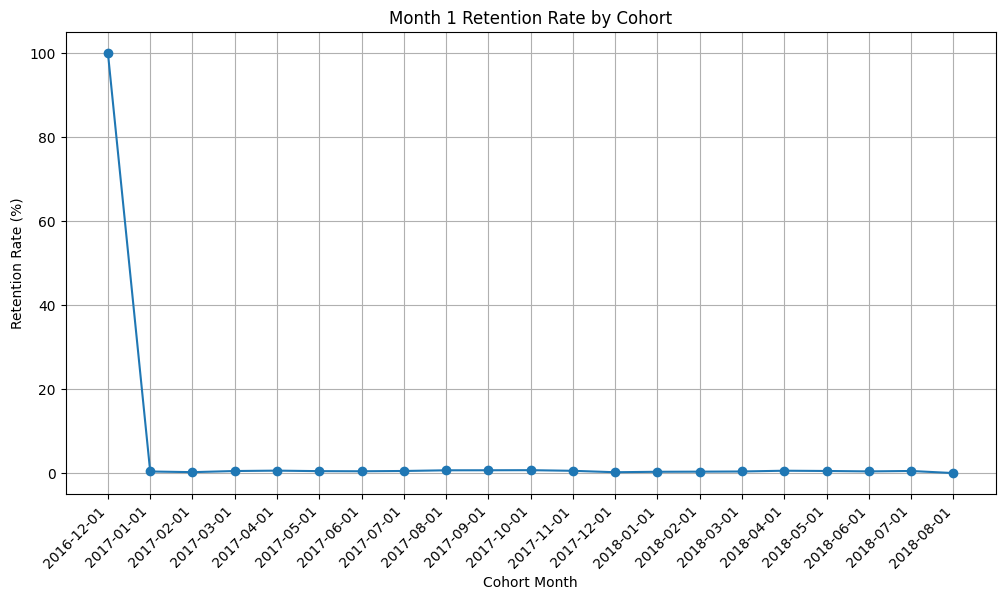

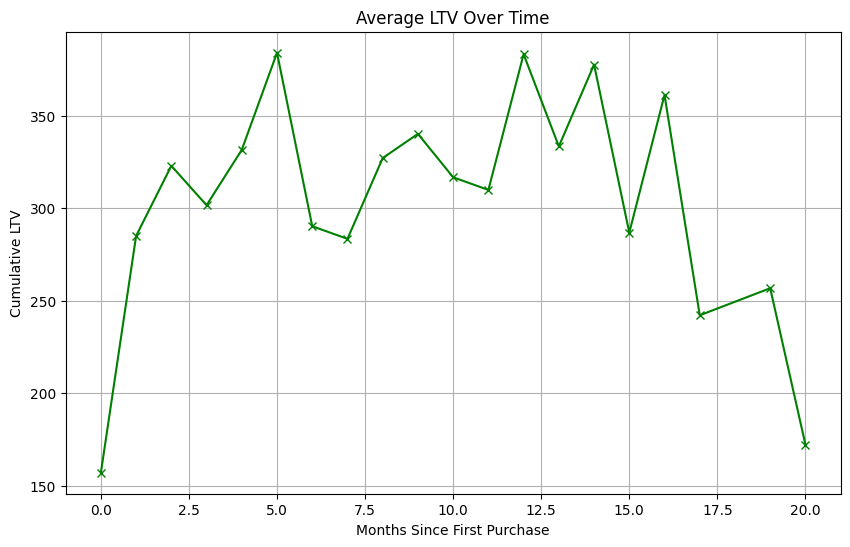

In [2]:
month_1_retention = df1[df1['months_since_first_purchase'] == 1]
fig1, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(month_1_retention['cohort_month'].astype(str), month_1_retention['retention_rate_pct'], marker='o')
ax1.set_title('Month 1 Retention Rate by Cohort')
ax1.set_xlabel('Cohort Month')
ax1.set_ylabel('Retention Rate (%)')
plt.xticks(rotation=45, ha='right')
ax1.grid(True)
fig1.savefig('../figures/02_retention_trend.png', bbox_inches='tight')
plt.show()

ltv_trend = df2.groupby('months_since_first_purchase')['avg_cumulative_ltv'].mean().reset_index()
fig2, ax2 = plt.subplots(figsize=(10, 6))
ax2.plot(ltv_trend['months_since_first_purchase'], ltv_trend['avg_cumulative_ltv'], marker='x', color='green')
ax2.set_title('Average LTV Over Time')
ax2.set_xlabel('Months Since First Purchase')
ax2.set_ylabel('Cumulative LTV')
ax2.grid(True)
fig2.savefig('../figures/02_ltv_growth.png', bbox_inches='tight')
plt.show()

### Key Findings
- Customer retention drops significantly after the first purchasing month.
- Lifetime value plateaus quickly, indicating lower historical repeat purchase behavior.